In [1]:
import sys
from pathlib import Path
import polars as pl

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

import torch
from datasets import load_dataset

from src.objects import AlignmentProblem, LatentSpace
from src.objects.latent import DimReductionMethod
from src.plotting.latent import plot_pc_correlation_heatmap


def _check_models_in_registry(model_a: str, model_b: str) -> None:
    """Check if models exist in the model registry."""
    model_df = pl.read_parquet('hf://datasets/spaicom-lab/model-registry/**/*.parquet')
    available_models = set(model_df['model_name'].unique().to_list())

    missing = []
    if model_a not in available_models:
        missing.append(model_a)
    if model_b not in available_models:
        missing.append(model_b)

    if missing:
        raise ValueError(
            f'Model(s) not found in model registry: {missing}\n'
            f'Available models: {sorted(available_models)[:20]}... (showing first 20)'
        )


def _check_models_in_dataset(model_a: str, model_b: str, dataset: str) -> None:
    """Check if models have embeddings in the dataset."""
    from datasets import get_dataset_config_names

    try:
        available = set(get_dataset_config_names(dataset))

        missing = []
        if model_a not in available:
            missing.append(model_a)
        if model_b not in available:
            missing.append(model_b)

        if missing:
            raise ValueError(
                f'Model(s) not found in dataset {dataset}: {missing}\n'
                f'Use scripts/encode_dataset_all_timm.py to encode missing models.'
            )
    except Exception as e:
        if isinstance(e, ValueError):
            raise
        raise ValueError(f'Error checking dataset {dataset}: {e}') from e


def main(
    model_a: str,
    model_b: str,
    dataset: str,
    method: DimReductionMethod,
    n_components: int = 50,
    k: int | None = None,
    n_anchors: int | None = None,
    output_path: str | None = None,
    repo_id: str = 'spaicom-lab',
    prefix: str = 'semantic-',
) -> None:
    """Plot correlation heatmap between principal components of two models."""

    _check_models_in_registry(model_a, model_b)

    full_dataset = f'{repo_id}/{prefix}{dataset}'
    _check_models_in_dataset(model_a, model_b, full_dataset)

    latent_a = _load_latent(model_a, full_dataset)
    latent_b = _load_latent(model_b, full_dataset)

    if n_anchors is not None:
        print(f'Aligning via relative representation (n_anchors={n_anchors}) ...')
        latent_a, latent_b = AlignmentProblem(latent_a, latent_b).align(
            'relative',
            strategy='prototype',
            n_anchors=n_anchors,
        )

    fig, ax = plot_pc_correlation_heatmap(
        latent_a=latent_a,
        latent_b=latent_b,
        method=method,
        n_components=n_components,
        k=k,
        label_a=model_a,
        label_b=model_b,
    )

    if n_anchors is not None:
        ax.set_title(
            ax.get_title().replace('PC correlation', f'PC correlation (relative, {n_anchors} anchors)'),
            fontsize=10,
            pad=8,
        )

    if output_path:
        fig.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f'Saved heatmap to {output_path}')
    else:
        fig.show()


def _load_latent(model: str, dataset: str) -> LatentSpace:
    """Load latent embeddings from HuggingFace dataset."""
    data = load_dataset(dataset, model, split='test').with_format('torch')
    latent = torch.vstack(list(data['embedding']))
    return LatentSpace(latent, seed=42)



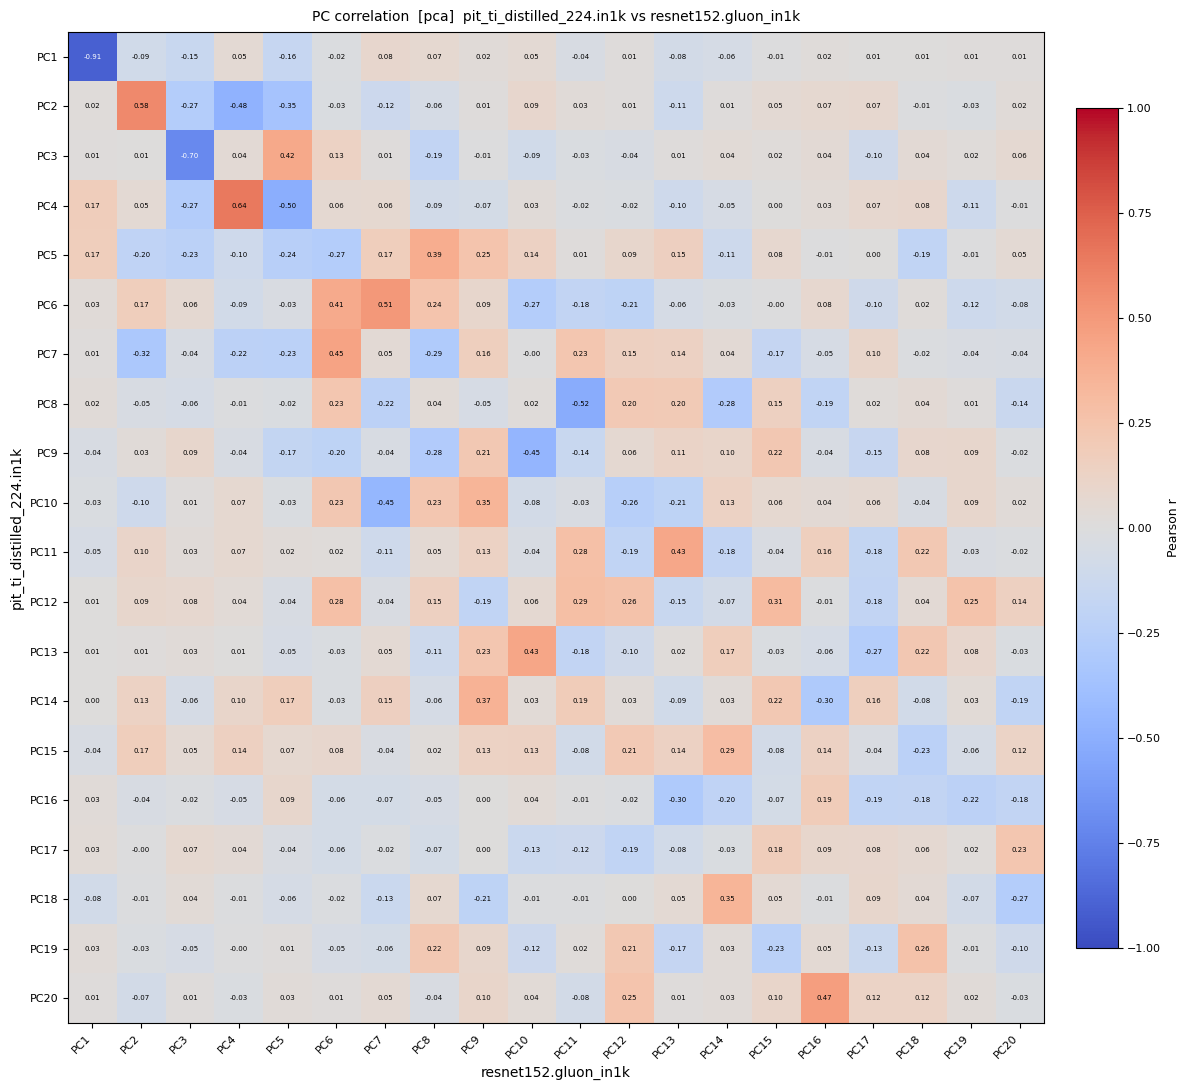

In [4]:
dataset = "cifar10"
# model_a = "vit_base_patch32_384.augreg_in1k"
model_a = "pit_ti_distilled_224.in1k"
model_b = "resnet152.gluon_in1k"
method = "pca"
n_components = 20
k = 20
main(
    model_a=model_a,
    model_b=model_b,
    dataset=dataset,
    method=method,
    n_components=n_components,
    k=k,
    output_path=None,
)


Aligning via relative representation (n_anchors=20) ...


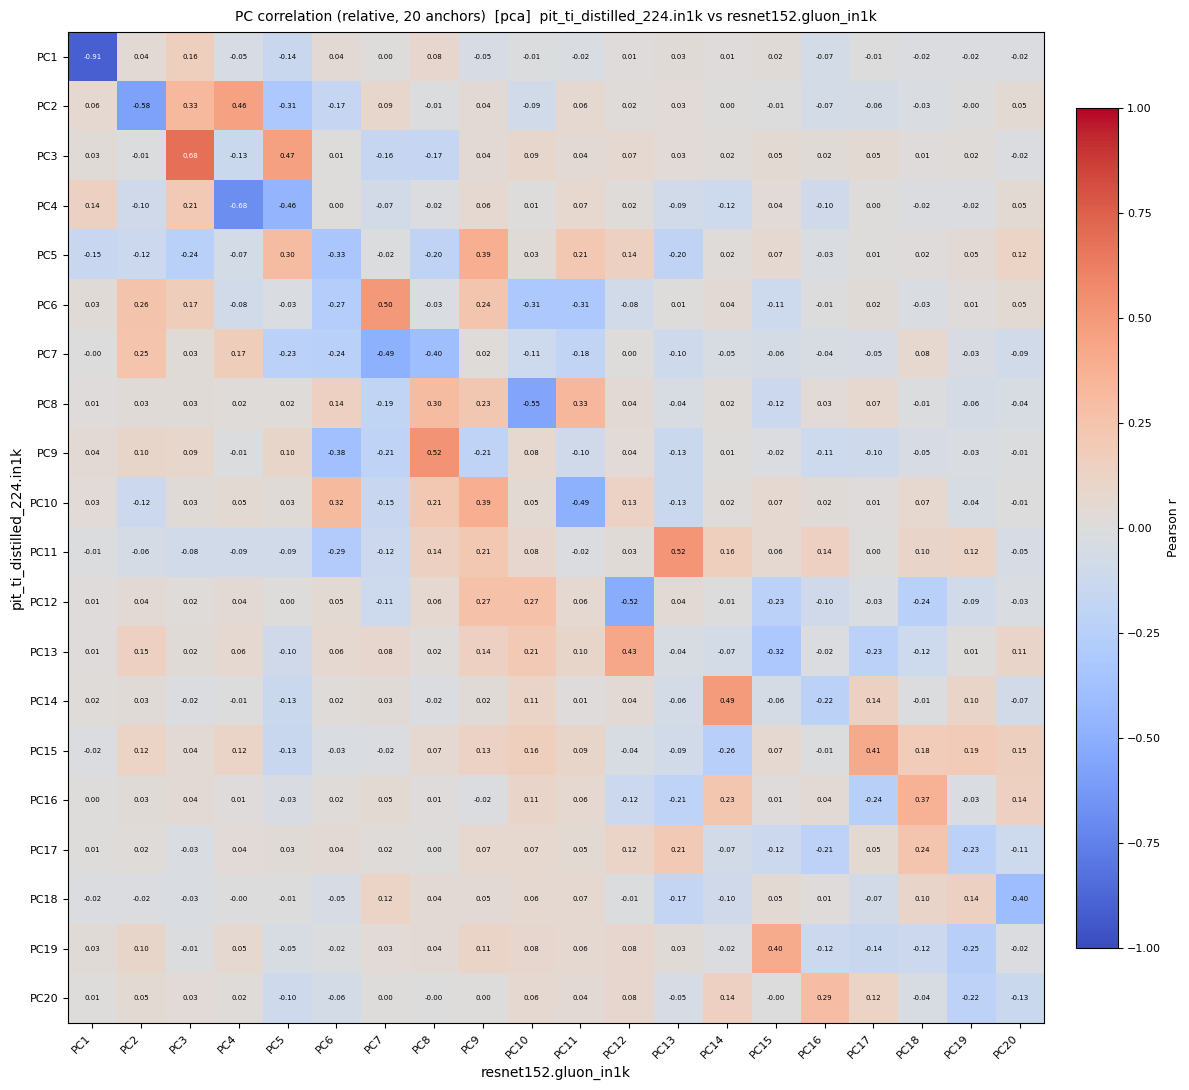

In [2]:
dataset = "cifar10"
# model_a = "vit_base_patch32_384.augreg_in1k"
model_a = "pit_ti_distilled_224.in1k"
model_b = "resnet152.gluon_in1k"
method = "pca"
n_components = 20
k = 20
main(
    model_a=model_a,
    model_b=model_b,
    dataset=dataset,
    method=method,
    n_components=n_components,
    k=k,
    n_anchors=20,
    output_path=None,
)

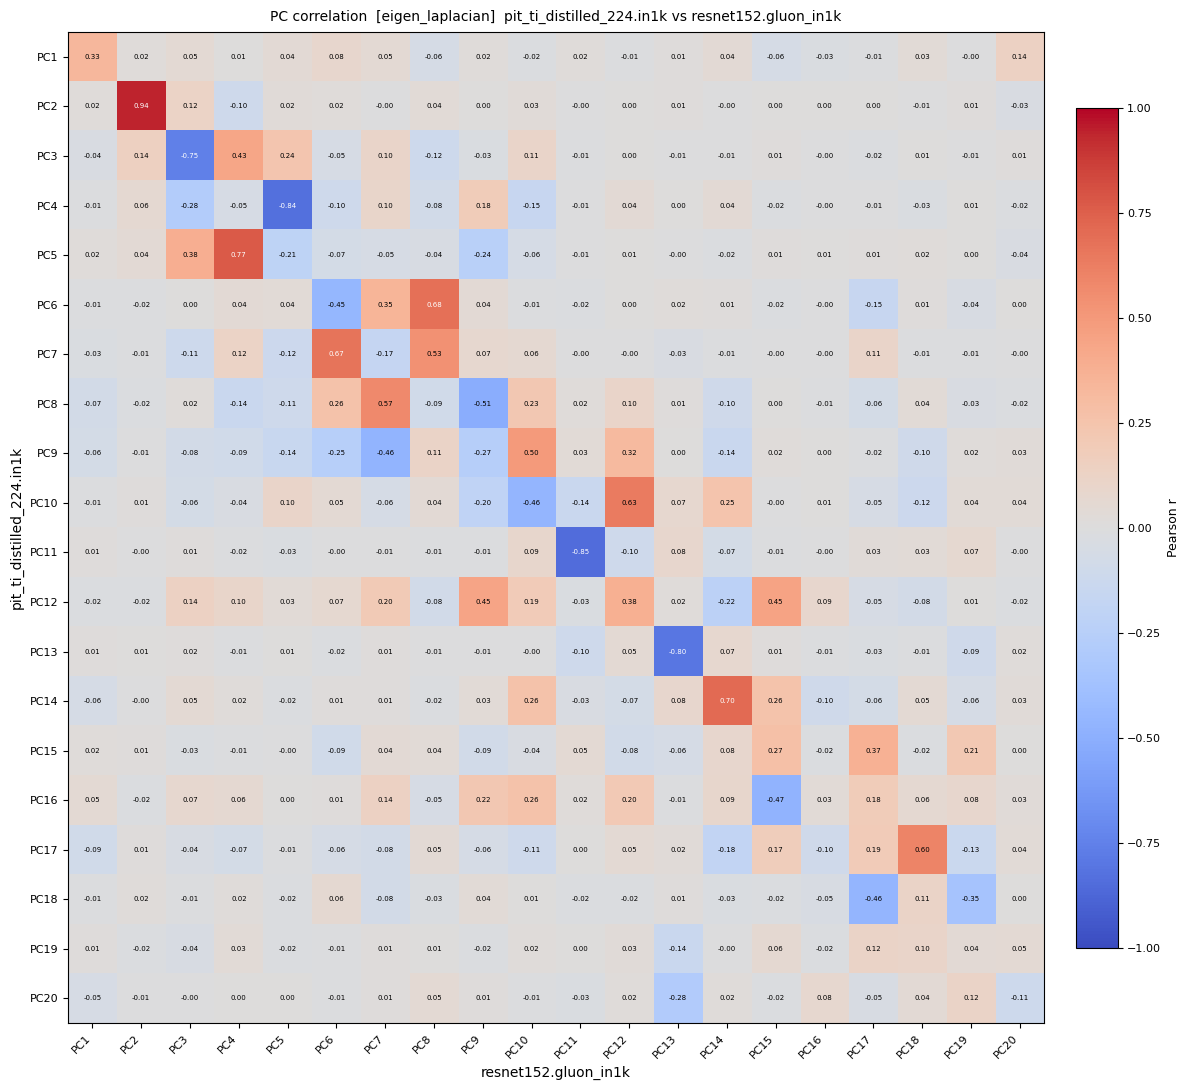

In [2]:
dataset = "cifar10"
# model_a = "vit_base_patch32_384.augreg_in1k"
model_a = "pit_ti_distilled_224.in1k"
model_b = "resnet152.gluon_in1k"
method = "eigen_laplacian"
n_components = 20
k = 20
main(
    model_a=model_a,
    model_b=model_b,
    dataset=dataset,
    method=method,
    n_components=n_components,
    k=k,
    output_path=None,
)

Aligning via relative representation (n_anchors=20) ...


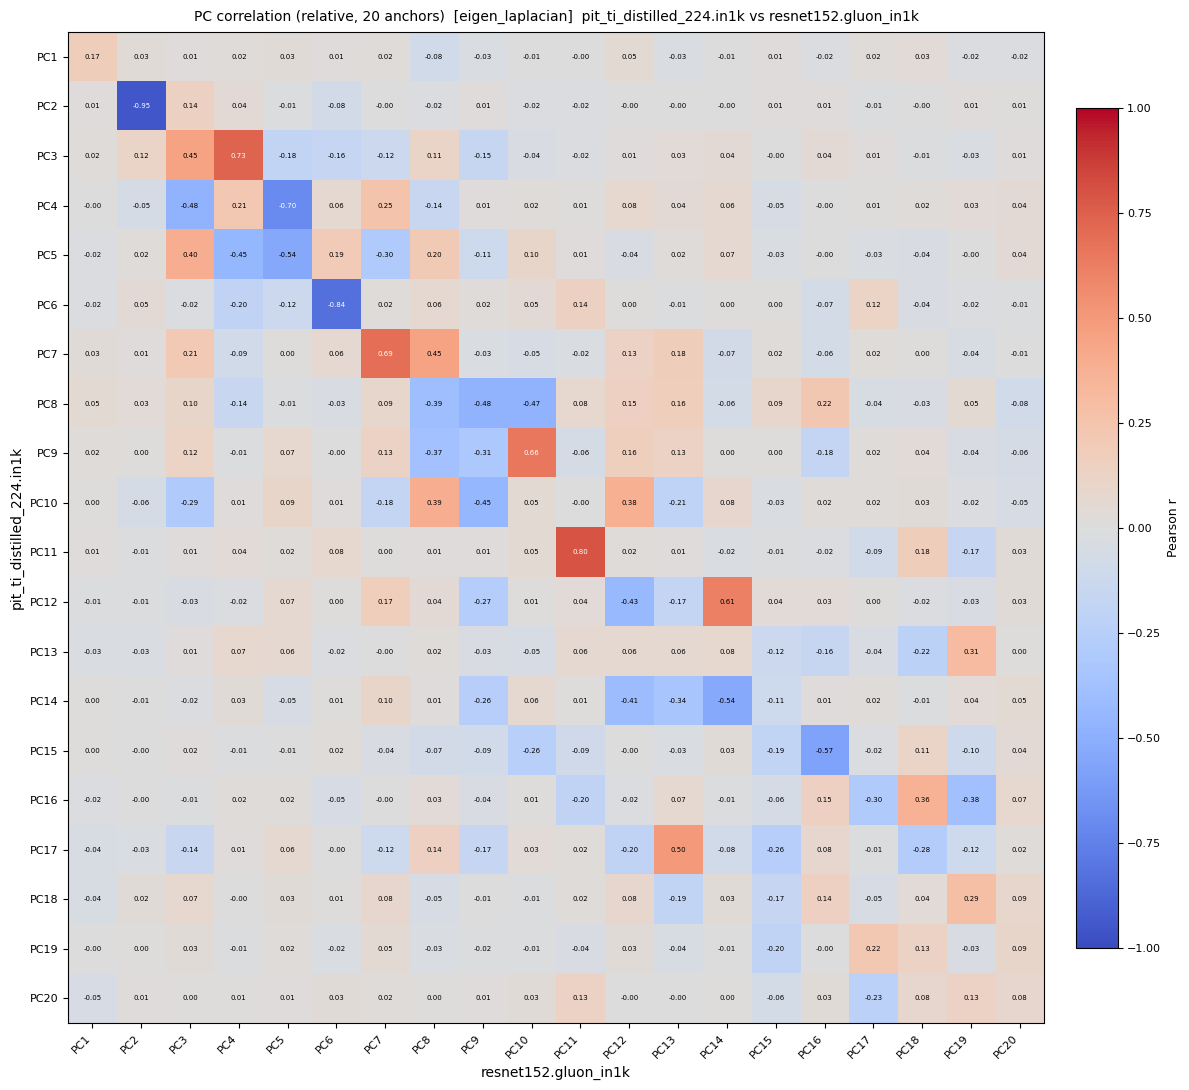

In [3]:
dataset = "cifar10"
# model_a = "vit_base_patch32_384.augreg_in1k"
model_a = "pit_ti_distilled_224.in1k"
model_b = "resnet152.gluon_in1k"
method = "eigen_laplacian"
n_components = 20
k = 20
main(
    model_a=model_a,
    model_b=model_b,
    dataset=dataset,
    method=method,
    n_components=n_components,
    k=k,
    n_anchors=20,
    output_path=None,
)

train/pit_ti_224.in1k/part-00000.parquet:   0%|          | 0.00/47.6M [00:00<?, ?B/s]

test/pit_ti_224.in1k/part-00000.parquet:   0%|          | 0.00/9.53M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

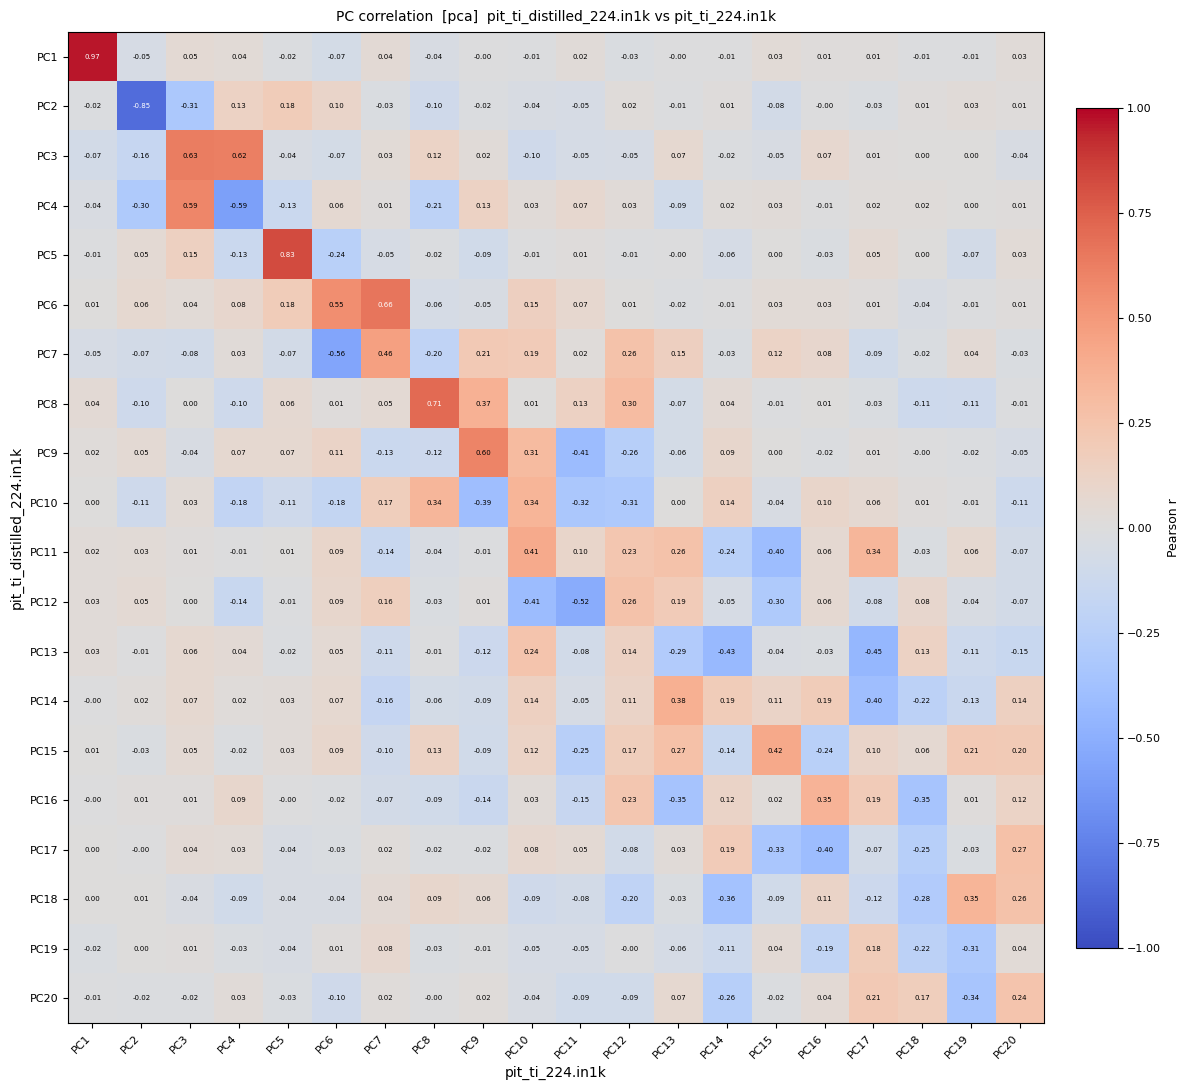

In [8]:
dataset = "cifar10"
# model_a = "vit_base_patch32_384.augreg_in1k"
model_a = "pit_ti_distilled_224.in1k"
model_b = "pit_ti_224.in1k"
method = "pca"
n_components = 20
k = 20
main(
    model_a=model_a,
    model_b=model_b,
    dataset=dataset,
    method=method,
    n_components=n_components,
    k=k,
    output_path=None,
)

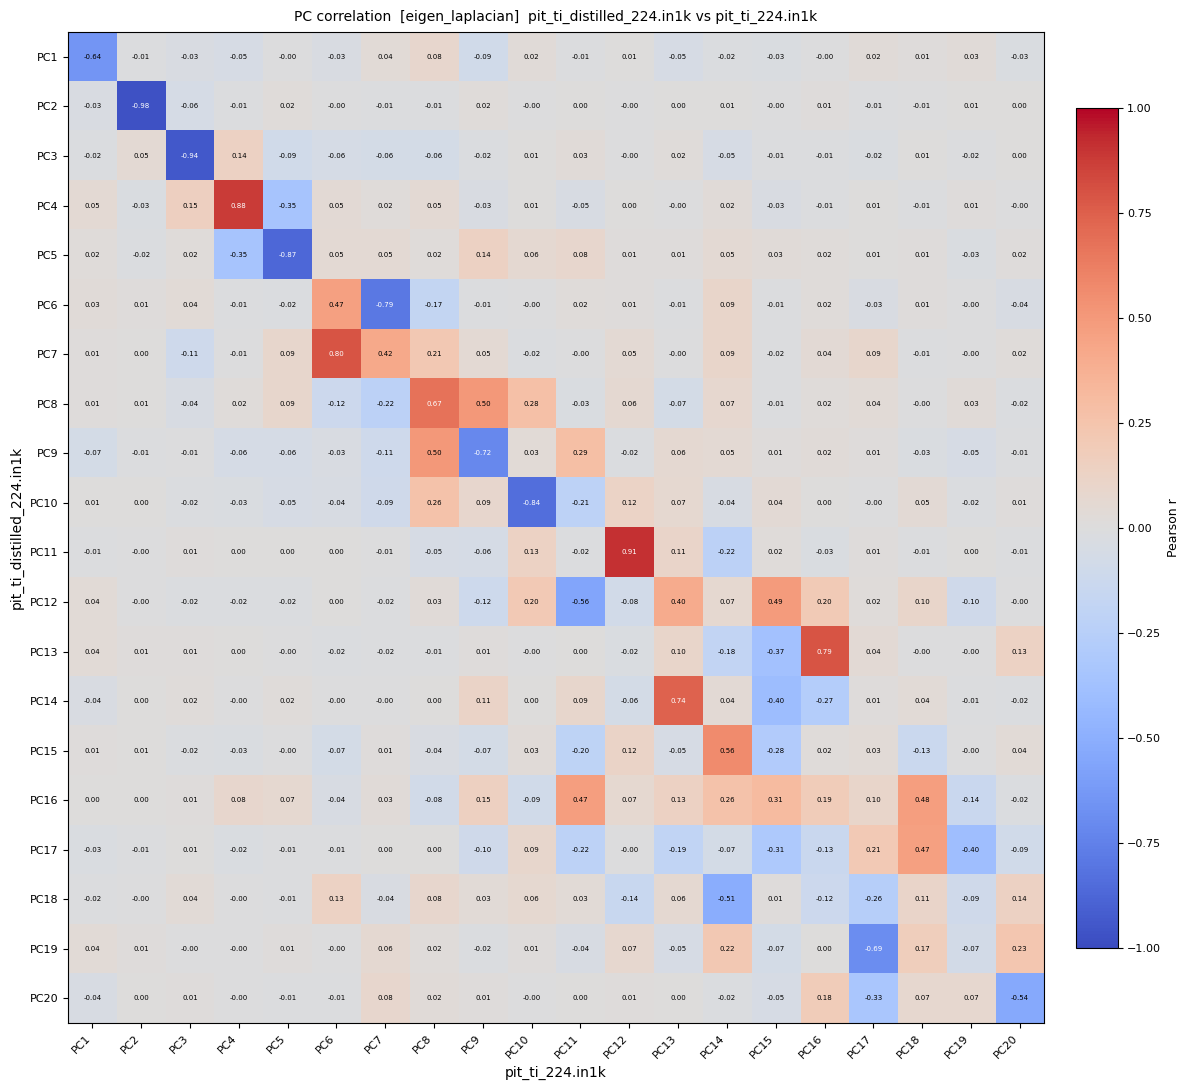

In [3]:
dataset = "cifar10"
# model_a = "vit_base_patch32_384.augreg_in1k"
model_a = "pit_ti_distilled_224.in1k"
model_b = "pit_ti_224.in1k"
method = "eigen_laplacian"
n_components = 20
k = 20
main(
    model_a=model_a,
    model_b=model_b,
    dataset=dataset,
    method=method,
    n_components=n_components,
    k=k,
    output_path=None,
)

train/resnet152s.gluon_in1k/part-00000.p(…):   0%|          | 0.00/371M [00:00<?, ?B/s]

test/resnet152s.gluon_in1k/part-00000.pa(…):   0%|          | 0.00/74.2M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

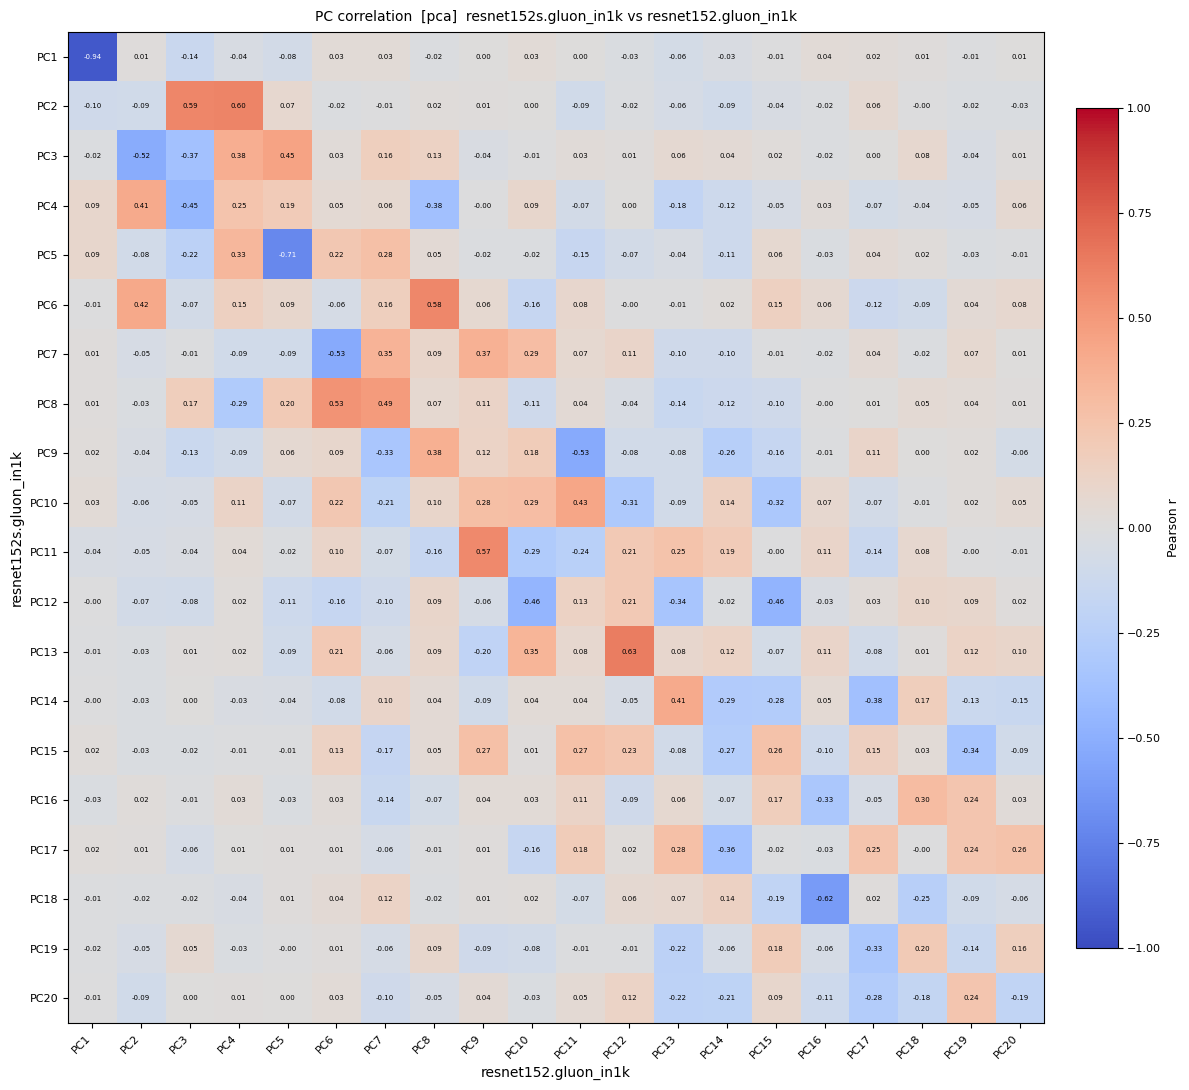

In [9]:
dataset = "cifar10"
# model_a = "vit_base_patch32_384.augreg_in1k"
model_a = "resnet152s.gluon_in1k"
model_b = "resnet152.gluon_in1k"
method = "pca"
n_components = 20
k = 20
main(
    model_a=model_a,
    model_b=model_b,
    dataset=dataset,
    method=method,
    n_components=n_components,
    k=k,
    output_path=None,
)
